In [74]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [76]:
data = pd.read_csv('ice_cream_selling_data.csv')
data.head()

,Temperature (C),Ice Cream Sales (units)
0,4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [80]:
# Let's create the independent variable and the dependent variable
X = data.iloc[:,0].values.reshape(-1,1)
y = data.iloc[:,1].values

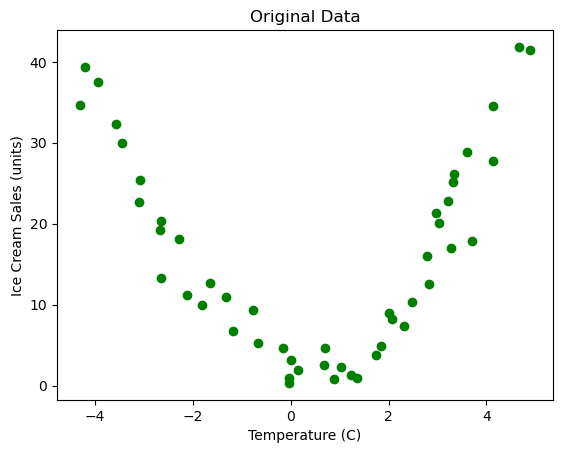

In [82]:
# Visualize the original datapoints
plt.scatter(X, y, color="green")
plt.title("Original Data")
plt.xlabel("Temperature (C)")
plt.ylabel("Ice Cream Sales (units)")
plt.show()

In [84]:
# 1. Split into training and testing sets FIRST (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [86]:
#  let's create a polynomial feature object with degree 2. 
degree = 2  # Degree of the polynomial
poly_features = PolynomialFeatures(degree=degree)

In [88]:
# ONLY fit the poly features on training data, then transform both
# transform the input data to include polynomial features
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

In [90]:
# Model training
# Train the model ONLY on training data
lr_model = LinearRegression()
#Now, fit the model (linear regression object) on the data
lr_model.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [92]:
# Generate predictions on the UNSEEN test data
y_test_pred = lr_model.predict(X_test_poly)

In [109]:
# 1. Create a dictionary with your actual and predicted test values
data_dict = {
    'Actual Values': y_test, 
    'Predicted Values': y_test_pred
}

# 2. Turn that dictionary into a Pandas DataFrame table
df = pd.DataFrame(data_dict)

# 3. Print the table to your screen
print(df)

   Actual Values  Predicted Values
0      10.012868         10.276208
1      17.843957         26.145463
2      27.698383         32.327326
3      28.912188         24.897186
4       9.392969          4.219624
5       2.313806          3.698845
6       0.789974          3.265895
7       4.625689          2.856050
8       4.857988          7.656040
9       4.673643          2.621985


Our model shows an R-squared score of around 0.834, which means that approximately 83% of data points are scattered around the fitted regression curve. Another interpretation is that 83% of the variation in the output variables is explained by the input variables.

An R² score of 0.834 means that your temperature data explains about 83.5% of the variation in ice cream sales. In data science, an R² above 0.80 on unseen test data is generally considered a strong, successful model.

In [94]:
 # Evaluating Model Performance
r2 = r2_score(y_test, y_test_pred)
print('R2_score:', r2)

R2_score: 0.8349058205436717


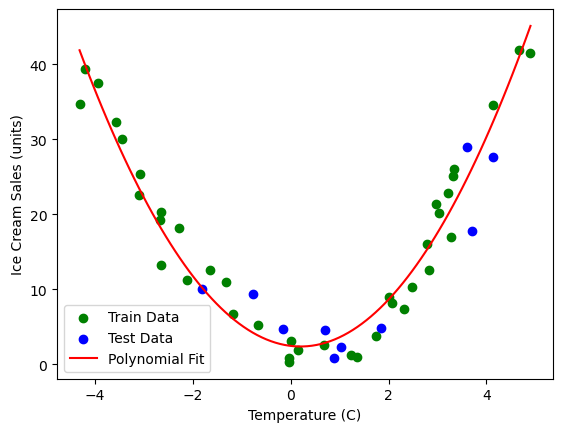

In [100]:
# 6. Visualize (Plot the smooth curve across the entire range)
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_poly = poly_features.transform(X_range)
y_range_pred = lr_model.predict(X_range_poly)

plt.scatter(X_train, y_train, color="green", label="Train Data")
plt.scatter(X_test, y_test, color="blue", label="Test Data")
plt.plot(X_range, y_range_pred, color="red", label="Polynomial Fit")
plt.xlabel("Temperature (C)")
plt.ylabel("Ice Cream Sales (units)")
plt.legend()
plt.show()

In [103]:
# Model Prediction for New Data
# Predict a new value
X_new = np.array([[1.9929]])  # Example value to predict
X_new_poly = poly_features.transform(X_new)
y_new_pred = lr_model.predict(X_new_poly)
print(y_new_pred)

[8.60458238]


The above result shows that the predicted value of Ice cream sales is 8.57450466.